## Monthly and weekly likelihood histograms

In [1]:
import autoroot

import os
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from datetime import timedelta

from notebooks.utils.patch_likelihoods import load_all_dataset_likelihoods

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
likelihood_dir_64x64 = os.environ.get('RESULTS_DIR_64x64')
datasets = ["goes_train", "goes_test", "ifs_train", "ifs_test", "icon_train", "icon_test"]
all_dataset_likelihoods = load_all_dataset_likelihoods(likelihood_dir_64x64, datasets)

for df in all_dataset_likelihoods.values():
    df['date'] = pd.to_datetime(df[['year', 'month', 'day']])

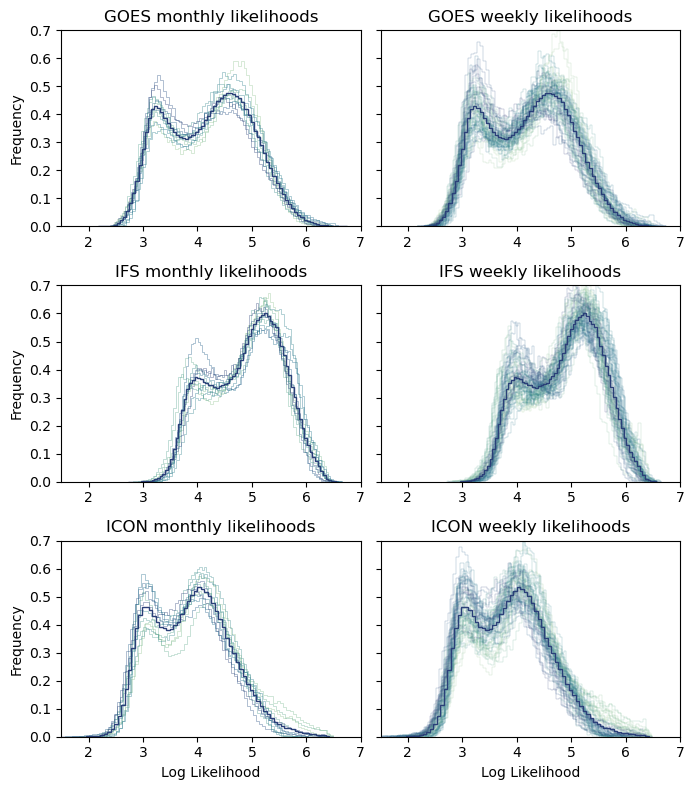

In [6]:
fig, axes = plt.subplots(3, 2, figsize=(7, 8), sharey=True)

datasets_order = ['goes', 'ifs', 'icon']

monthly_palette = sns.color_palette("crest", n_colors=12)
weekly_palette = sns.color_palette("crest", n_colors=52)

for row_idx, dataset in enumerate(datasets_order):
    df = all_dataset_likelihoods[dataset]

    # Left column: monthly curves overlaid with year average
    ax = axes[row_idx, 0]

    for month in range(1, 13):
        df_month = df[df['month'] == month]
        if df_month.empty:
            continue
        ax.hist(
            df_month['bpd'],
            bins=80,
            density=True,
            histtype='step',
            color=monthly_palette[month - 1],
            linewidth=0.5,
            alpha=0.5,
        )

    ax.hist(
        df['bpd'],
        bins=80,
        density=True,
        histtype='step',
        color=mcolors.to_hex(monthly_palette[-1]),
        linewidth=1,
    )

    ax.set_xlim(1.5, 7)
    ax.set_title(f'{dataset.upper()} monthly likelihoods')
    ax.set_ylabel('Frequency')

    # Right column: weekly curves (7-day windows) overlaid with year average
    ax = axes[row_idx, 1]

    start_date = df['date'].min()
    end_date = df['date'].max()
    current_start = start_date
    week_idx = 0

    while current_start + timedelta(days=7) <= end_date:
        current_end = current_start + timedelta(days=7)
        df_week = df[(df['date'] >= current_start) & (df['date'] < current_end)]

        if not df_week.empty:
            ax.hist(
                df_week['bpd'],
                bins=80,
                density=True,
                histtype='step',
                color=weekly_palette[week_idx % len(weekly_palette)],
                linewidth=0.3,
                alpha=0.5,
            )

        current_start = current_end
        week_idx += 1

    ax.hist(
        df['bpd'],
        bins=80,
        density=True,
        histtype='step',
        color=mcolors.to_hex(monthly_palette[-1]),
        linewidth=1,
    )

    ax.set_xlim(1.5, 7)
    ax.set_ylim(0, 0.7)
    ax.set_title(f'{dataset.upper()} weekly likelihoods')

for ax in axes[2, :]:
    ax.set_xlabel('Log Likelihood')

plt.tight_layout()
plt.show()